Trial 15 Complete [00h 00m 14s]
val_loss: 0.000569124473258853

Best val_loss So Far: 0.0004391981929074973
Total elapsed time: 00h 04m 38s

--- Tuning Optimization Complete! Best Hyperparameters: ---
-> Base Input Units: 256
-> Hidden Layer Count: 1
-> Bottleneck Layer Units: 32
-> Learning Rate: 0.01

--- Training Final Optimal Model Configuration ---
Epoch 1/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3593 - mae: 0.2861 - val_loss: 0.0223 - val_mae: 0.1303 - learning_rate: 0.0100
Epoch 2/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0117 - mae: 0.0843 - val_loss: 0.0185 - val_mae: 0.1117 - learning_rate: 0.0100
Epoch 3/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0063 - mae: 0.0620 - val_loss: 0.0084 - val_mae: 0.0744 - learning_rate: 0.0100
Epoch 4/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - mae: 0.0579 - val_loss: 0.0048 - val_mae: 0.0552 - learning_rate: 0.0100
Epoch 5/300
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0069 - mae: 0.0640

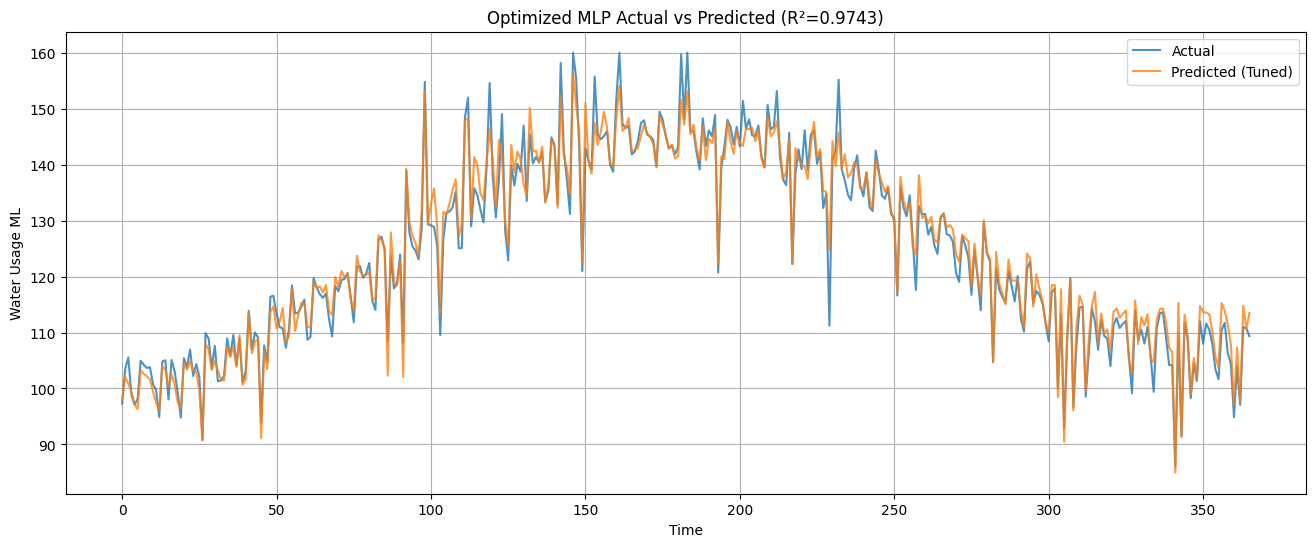

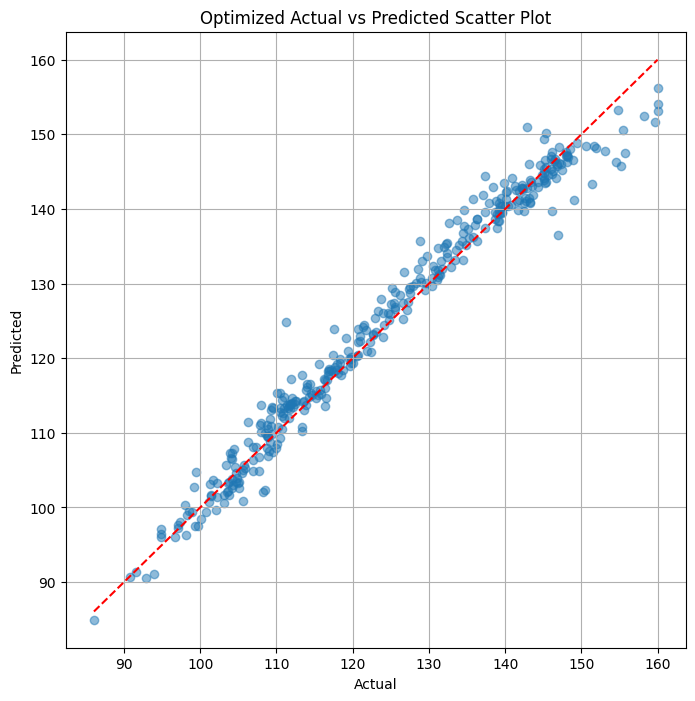

In [ ]:
%pip install numpy pandas matplotlib scikit-learn tensorflow keras-tuner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
   
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
import keras_tuner as kt


df = pd.read_csv("water_consumption_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

target = "Total_Daily_Usage_ML"


df['month_sin'] = np.sin(2*np.pi*df['Month']/12)
df['month_cos'] = np.cos(2*np.pi*df['Month']/12)
df['day_sin'] = np.sin(2*np.pi*df['Day_of_Year']/365)
df['day_cos'] = np.cos(2*np.pi*df['Day_of_Year']/365)


for lag in [1,2,3,4,5,7,14,21,30,60,90,180,365]:
    df[f'lag_{lag}'] = df[target].shift(lag)


df['ma_7'] = df[target].rolling(7).mean()
df['ma_30'] = df[target].rolling(30).mean()
df['std_7'] = df[target].rolling(7).std()
df['std_30'] = df[target].rolling(30).std()
df['ema_7'] = df[target].ewm(span=7).mean()
df['ema_30'] = df[target].ewm(span=30).mean()
df['diff_1'] = df[target].diff(1)
df['diff_7'] = df[target].diff(7)
df['pct_change_1'] = df[target].pct_change()
df['pct_change_7'] = df[target].pct_change(7)

df.dropna(inplace=True)


features = [
    'Day_of_Week', 'Month', 'Year', 'Day_of_Year', 'Is_Weekend', 'Holiday_Flag',
    'Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Evaporation_Rate_mm',
    'Population', 'Household_Count', 'Urbanization_Index', 'Pump_Status', 'Reservoir_Level_pct',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30', 'lag_60', 'lag_90', 'lag_180', 'lag_365',
    'ma_7', 'ma_30', 'std_7', 'std_30', 'ema_7', 'ema_30', 'diff_1', 'diff_7', 'pct_change_1', 'pct_change_7'
]

split = int(len(df) * 0.8)
train_df = df.iloc[:split]
test_df = df.iloc[split:]


feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train = feature_scaler.fit_transform(train_df[features])
X_test = feature_scaler.transform(test_df[features])

y_train = target_scaler.fit_transform(train_df[[target]])
y_test = target_scaler.transform(test_df[[target]])


def build_model(hp):
    model = Sequential()
    

    model.add(Dense(
        units=hp.Int('units_input', min_value=128, max_value=512, step=64),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    if hp.Boolean('use_bn_input'):
        model.add(BatchNormalization())
    model.add(Dropout(rate=hp.Float('dropout_input', min_value=0.1, max_value=0.4, step=0.1)))
    
   
    for i in range(hp.Int('num_hidden_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_layer_{i}', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        if hp.Boolean(f'use_bn_layer_{i}'):
            model.add(BatchNormalization())
        model.add(Dropout(rate=hp.Float(f'dropout_layer_{i}', min_value=0.0, max_value=0.3, step=0.1)))
        

    model.add(Dense(
        units=hp.Int('units_bottleneck', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    

    model.add(Dense(1))
    

    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=15,             
    executions_per_trial=1,    
    directory='mlp_tuning_dir',
    project_name='water_demand_mlp'
)

tune_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
tune_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

print("--- Starting Hyperparameter Search ---")
tuner.search(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=100,               
    batch_size=32,
    callbacks=[tune_early_stop, tune_reduce_lr],
    verbose=1
)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n--- Tuning Optimization Complete! Best Hyperparameters: ---")
print(f"-> Base Input Units: {best_hps.get('units_input')}")
print(f"-> Hidden Layer Count: {best_hps.get('num_hidden_layers')}")
print(f"-> Bottleneck Layer Units: {best_hps.get('units_bottleneck')}")
print(f"-> Learning Rate: {best_hps.get('learning_rate')}")

print("\n--- Training Final Optimal Model Configuration ---")
model = tuner.hypermodel.build(best_hps)

final_early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
final_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=32,
    callbacks=[final_early_stop, final_reduce_lr],
    verbose=1
)

predictions = model.predict(X_test)
predictions_actual = target_scaler.inverse_transform(predictions)
y_test_actual = target_scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
r2 = r2_score(y_test_actual, predictions_actual)

print("\nRESULTS (OPTIMIZED MODEL)")
print("=========================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print("=========================")


